In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('diabetes.csv')

# About Data

In [4]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
386,5,116,74,29,0,32.3,0.660,35,1
654,1,106,70,28,135,34.2,0.142,22,0
71,5,139,64,35,140,28.6,0.411,26,0
114,7,160,54,32,175,30.5,0.588,39,1
273,1,71,78,50,45,33.2,0.422,21,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Complete EDA

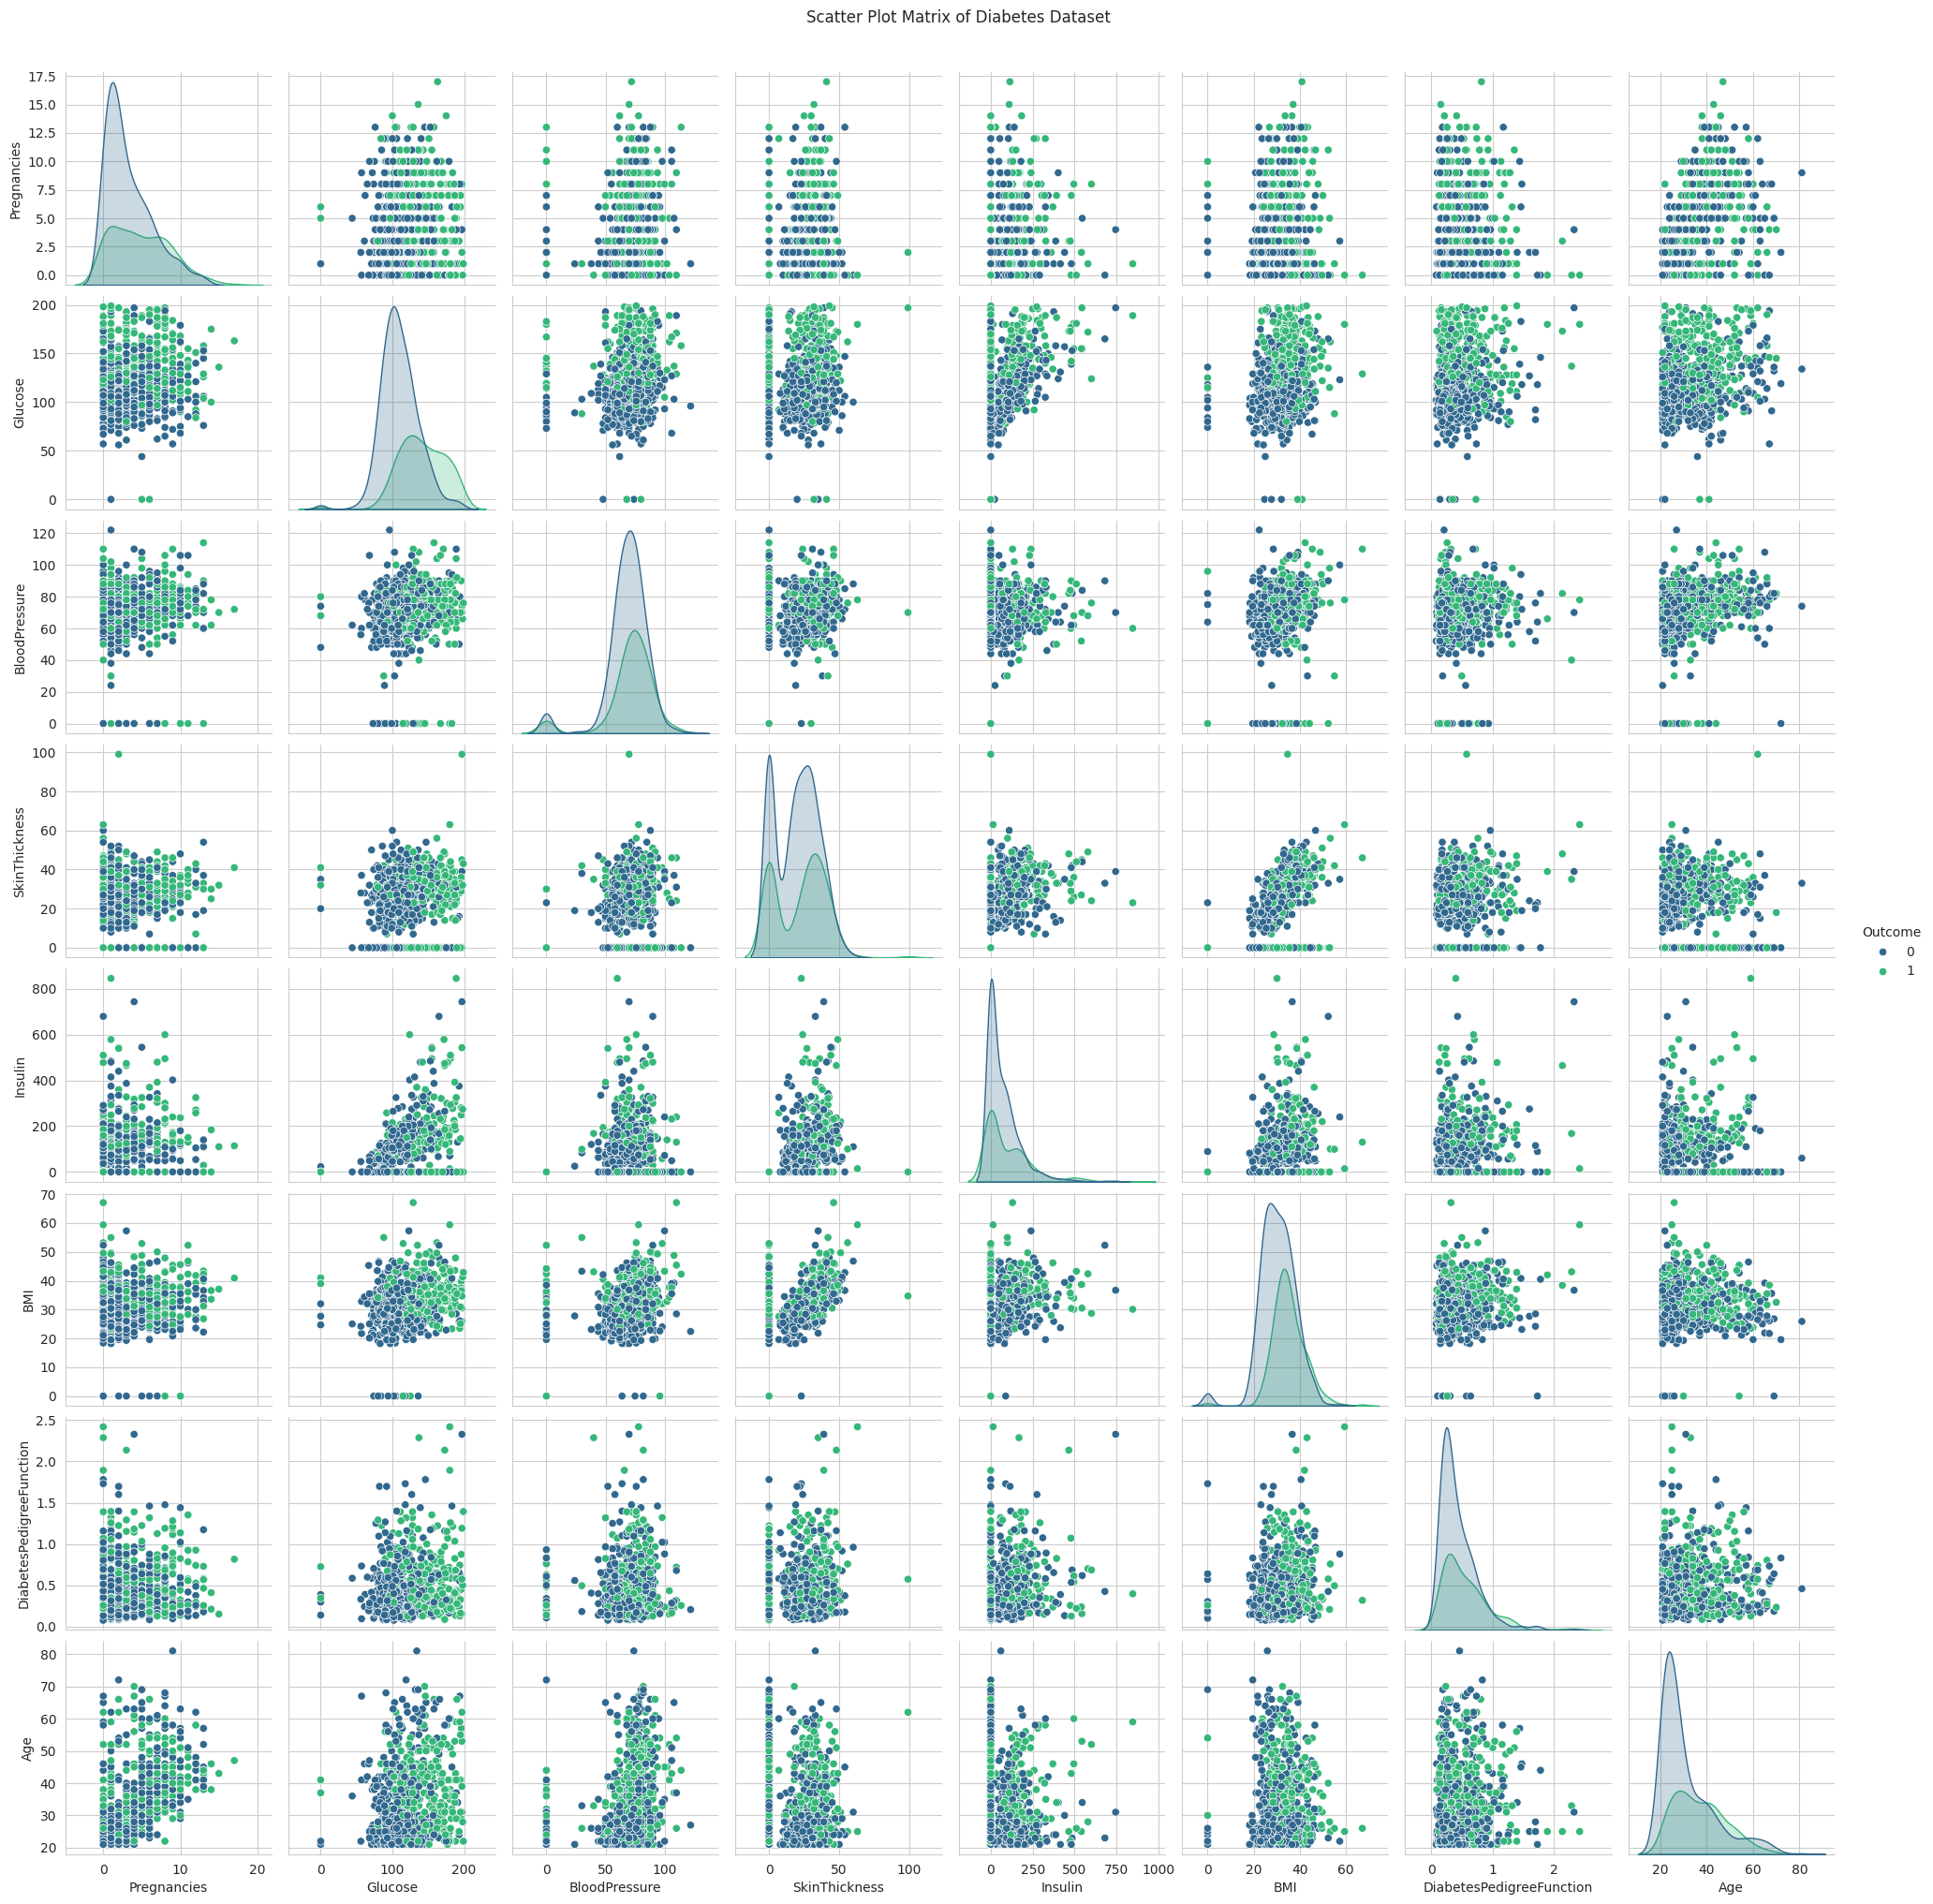

In [9]:
sns.set_style("whitegrid")
pair_plot = sns.pairplot(df, hue='Outcome', diag_kind='kde', palette='viridis')

plt.suptitle("Scatter Plot Matrix of Diabetes Dataset", y=1.02)
plt.show()

In [10]:
matrix_corr = df.corr()

In [11]:
matrix_corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [12]:
print(matrix_corr['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [13]:
#chose glu,bmi,age
df_final = df[['Glucose','BMI','Age','Outcome']]

In [14]:
df_final.shape

(768, 4)

In [15]:
df_final.sample(5)

,Glucose,BMI,Age,Outcome
272,122,23.0,40,0
639,100,19.5,28,0
319,194,23.5,59,1
290,78,36.9,21,0
688,140,24.1,23,0


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_final.iloc[:,:-1],
                                                    df_final.iloc[:,-1],
                                                    test_size=0.2,
                                                    random_state=42)

#Logistic Regression From Scratch

In [17]:
class my_LR:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def loss(self, y_true, y_pred):
        epsilon = 1e-9
        return -np.mean(
            y_true * np.log(y_pred + epsilon) +
            (1 - y_true) * np.log(1 - y_pred + epsilon)
        )

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            linear_output = np.dot(X, self.weights) + self.bias


            y_pred = self.sigmoid(linear_output)


            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)

#Prediction

In [18]:
lr = my_LR()

In [19]:
lr.fit(X_train, y_train)

In [20]:
y_pred = lr.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6428571428571429

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

lr2 = LogisticRegression()
lr2.fit(X_train, y_train)
y_pred = lr2.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7467532467532467


In [80]:
m1 = -(lr2.coef_[0][0]/lr2.coef_[0][1])
b1 = -(lr2.intercept_[0]/lr2.coef_[0][1])
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1
lr2.coef_

array([[0.0309458 , 0.09468367, 0.04366426]])

Accuracy  : 0.7467532467532467
Coef_     : [[0.0309458  0.09468367 0.04366426]]
Intercept : [-9.08607792]


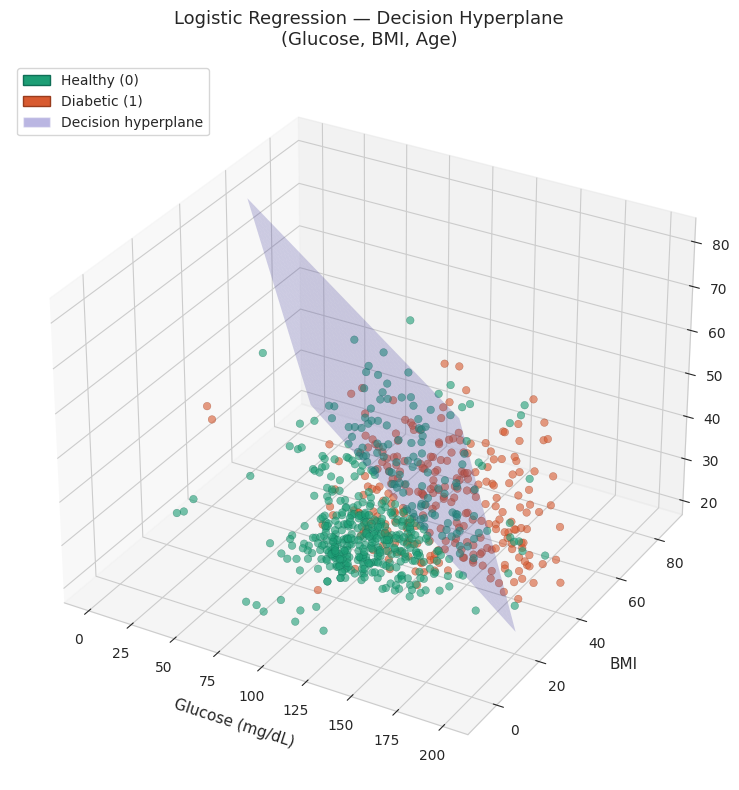

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv("diabetes.csv")

X = df[["Glucose", "BMI", "Age"]].values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr2 = LogisticRegression()
lr2.fit(X_train, y_train)
y_pred = lr2.predict(X_test)

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Coef_     :", lr2.coef_)      # [w_glucose, w_bmi, w_age]
print("Intercept :", lr2.intercept_)

w0, w1, w2 = lr2.coef_[0]
b            = lr2.intercept_[0]

# Hyperplane: w0*Glucose + w1*BMI + w2*Age + b = 0
# Solve for BMI: BMI = -(w0*Glucose + w2*Age + b) / w1
glucose_range = np.linspace(df["Glucose"].min(), df["Glucose"].max(), 40)
age_range     = np.linspace(df["Age"].min(),     df["Age"].max(),     40)
G, A          = np.meshgrid(glucose_range, age_range)
BMI_plane     = -(w0 * G + w2 * A + b) / w1

healthy  = df[df["Outcome"] == 0]
diabetic = df[df["Outcome"] == 1]

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection="3d")

ax.scatter(healthy["Glucose"],  healthy["BMI"],  healthy["Age"],
           color="#1D9E75", alpha=0.6, s=30, edgecolors="#0F6E56",
           linewidths=0.3, label="Healthy (0)")

ax.scatter(diabetic["Glucose"], diabetic["BMI"], diabetic["Age"],
           color="#D85A30", alpha=0.6, s=30, edgecolors="#993C1D",
           linewidths=0.3, label="Diabetic (1)")

ax.plot_surface(G, BMI_plane, A,
                alpha=0.25, color="#534AB7",
                rstride=1, cstride=1, linewidth=0)

ax.set_xlabel("Glucose (mg/dL)", fontsize=11, labelpad=8)
ax.set_ylabel("BMI",             fontsize=11, labelpad=8)
ax.set_zlabel("Age",             fontsize=11, labelpad=8)
ax.set_title("Logistic Regression — Decision Hyperplane\n(Glucose, BMI, Age)",
             fontsize=13, pad=12)

ax.legend(fontsize=10, loc="upper left")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", edgecolor="#0F6E56", label="Healthy (0)"),
    Patch(facecolor="#D85A30", edgecolor="#993C1D", label="Diabetic (1)"),
    Patch(facecolor="#534AB7", alpha=0.4,           label="Decision hyperplane"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("decision_hyperplane_3d.png", dpi=150)
plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
dt = DecisionTreeClassifier(max_depth=2)

In [68]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

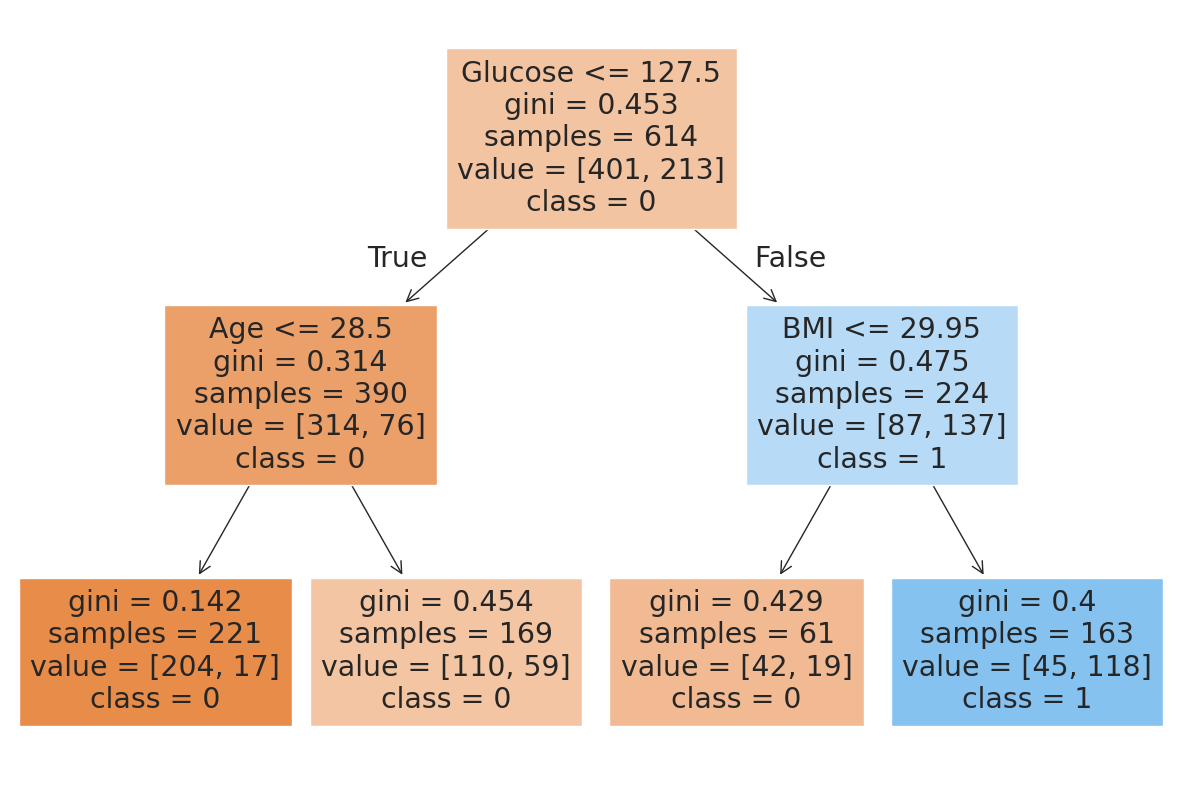

In [69]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt, filled=True, feature_names=X_train.columns, class_names=['0', '1'])
plt.show()

In [70]:
y_pred = dt.predict(X_test)

In [71]:
print(accuracy_score(y_test, y_pred))

0.7727272727272727


In [27]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=600, random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7402597402597403


In [28]:
n_estimators = [20,60,100,120]
max_features = [0.2,0.6,1.0]
max_depth = [2,8,None]
max_samples = [0.5,0.75,1.0]


In [29]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0]}


In [41]:
from sklearn.model_selection import GridSearchCV
rf_grid = GridSearchCV(estimator = rf,
                       param_grid = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [42]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=600,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [43]:
rf_grid.best_score_

np.float64(0.7866853258696522)

In [44]:
rf_grid.best_estimator_

RandomForestClassifier(max_depth=8, max_features=0.2, max_samples=0.75,
                       n_estimators=20, random_state=42)

In [45]:
df_final

,Glucose,BMI,Age,Outcome
0,148,33.6,50,1
1,85,26.6,31,0
2,183,23.3,32,1
3,89,28.1,21,0
4,137,43.1,33,1
...,...,...,...,...
763,101,32.9,63,0
764,122,36.8,27,0
765,121,26.2,30,0
766,126,30.1,47,1


<Figure size 800x600 with 0 Axes>

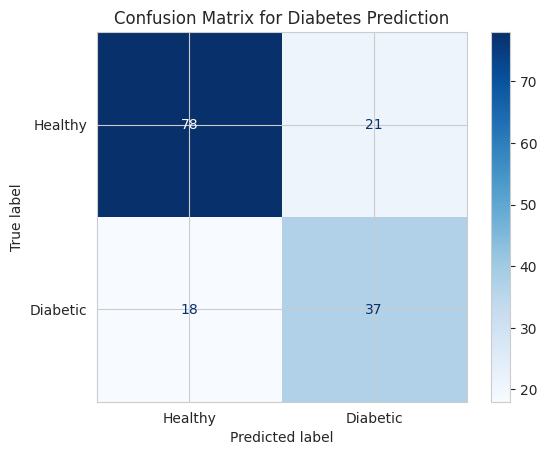

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf_grid.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
cmd.plot(cmap='Blues')

plt.title('Confusion Matrix for Diabetes Prediction')
plt.show()